In [1]:
import pandas as pd

In [2]:
train = pd.read_csv("train_features.csv")

In [3]:
X_train = pd.read_csv("train_scaled.csv")


## LSTM(Long Short Term Memory) Model

In [4]:
feature_cols = X_train.columns.tolist()

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 18
['cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [5]:
feature_cols = [
    col for col in X_train.columns
    if col != 'cycle'
]

In [6]:
feature_cols

['op_setting_1',
 'op_setting_2',
 'op_setting_3',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_17',
 'sensor_20',
 'sensor_21']

In [10]:
joblib.dump(feature_cols, "feature_columns_lstm.pkl")

['feature_columns_lstm.pkl']

In [6]:
from sklearn.model_selection import GroupShuffleSplit

X = train[feature_cols]
y = train['RUL']
groups = train['engine_id']

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]

In [7]:
train_engines = train.iloc[train_idx]['engine_id'].unique()
val_engines = train.iloc[val_idx]['engine_id'].unique()

print("Training engines:", len(train_engines))
print("Validation engines:", len(val_engines))

print("Training engine IDs:", train_engines)
print("Validation engine IDs:", val_engines)

Training engines: 80
Validation engines: 20
Training engine IDs: [  2   3   4   6   7   8   9  10  12  14  15  16  17  18  20  21  22  24
  25  26  27  28  29  30  33  35  36  37  38  39  41  42  43  44  47  48
  49  50  51  52  53  55  56  57  58  59  60  61  62  63  64  65  66  67
  68  69  70  72  73  75  76  79  80  82  83  85  86  87  88  89  90  92
  93  94  95  96  97  98  99 100]
Validation engine IDs: [ 1  5 11 13 19 23 31 32 34 40 45 46 54 71 74 77 78 81 84 91]


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)

X_val_scaled = scaler.transform(X_val)

In [9]:
import joblib

joblib.dump(scaler, "scaler_lstm.pkl")

['scaler_lstm.pkl']

In [10]:
train_seq_df = train[train['engine_id'].isin(train_engines)].copy()
val_seq_df = train[train['engine_id'].isin(val_engines)].copy()

In [11]:
train_scaled = X_train.copy()

train_scaled.loc[:, feature_cols] = X_train_scaled

train_scaled['engine_id'] = train_seq_df['engine_id'].values
train_scaled['cycle'] = train_seq_df['cycle'].values
train_scaled['RUL'] = train_seq_df['RUL'].values

C:\Users\Admin\AppData\Local\Temp\ipykernel_15292\324554771.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.42624592 -0.77952854 -1.42624592 ...  3.1007757   1.16062358
  1.80734095]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_scaled.loc[:, feature_cols] = X_train_scaled


In [12]:
train_scaled = train.iloc[train_idx][
    ['engine_id', 'cycle'] + feature_cols + ['RUL']
].copy()

val_scaled = train.iloc[val_idx][
    ['engine_id', 'cycle'] + feature_cols + ['RUL']
].copy()

In [13]:
train_scaled[feature_cols] = X_train_scaled
val_scaled[feature_cols] = X_val_scaled

In [14]:
train_scaled = train_scaled.sort_values(
    ['engine_id', 'cycle']
).reset_index(drop=True)

val_scaled = val_scaled.sort_values(
    ['engine_id', 'cycle']
).reset_index(drop=True)

### Sequence Function

In [15]:
import numpy as np

WINDOW_SIZE = 30

def create_sequences(df, feature_cols, window_size=30):
    
    X = []
    y = []
    
    for engine_id in df['engine_id'].unique():
        
        engine_data = df[
            df['engine_id'] == engine_id
        ].sort_values('cycle')
        
        features = engine_data[feature_cols].values
        rul = engine_data['RUL'].values
        
        # Need at least window_size cycles
        if len(engine_data) < window_size:
            continue
        
        for i in range(len(engine_data) - window_size + 1):
            
            X.append(
                features[i:i + window_size]
            )
            
            # RUL corresponding to the last cycle
            y.append(
                rul[i + window_size - 1]
            )
    
    return np.array(X), np.array(y)

In [16]:
X_train_lstm, y_train_lstm = create_sequences(
    train_scaled,
    feature_cols,
    WINDOW_SIZE
)

In [17]:
X_val_lstm, y_val_lstm = create_sequences(
    val_scaled,
    feature_cols,
    WINDOW_SIZE
)

In [18]:
print("X_train_lstm:", X_train_lstm.shape)
print("y_train_lstm:", y_train_lstm.shape)

print("X_val_lstm:", X_val_lstm.shape)
print("y_val_lstm:", y_val_lstm.shape)

X_train_lstm: (14241, 30, 17)
y_train_lstm: (14241,)
X_val_lstm: (3490, 30, 17)
y_val_lstm: (3490,)


In [19]:
print("Sequence mean:", X_train_lstm.mean())
print("Sequence std:", X_train_lstm.std())

Sequence mean: -0.02622107408060175
Sequence std: 0.8769988688724236


In [21]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [34]:
model = Sequential([
    
    LSTM(
        64,
        input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])
    ),
    
    Dropout(0.2),
    
    Dense(32, activation='relu'),
    
    Dense(1)
])

d:\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [35]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,105 (90.25 KB)

 Trainable params: 23,105 (90.25 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

In [23]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

In [39]:
history = model.fit(
    X_train_lstm,
    y_train_lstm,
    
    validation_data=(
        X_val_lstm,
        y_val_lstm
    ),
    
    epochs=50,
    batch_size=64,
    
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    
    verbose=1
)

Epoch 1/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 7163.2949 - mae: 63.9489 - val_loss: 1945.1196 - val_mae: 32.7563 - learning_rate: 0.0010
Epoch 2/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1788.0746 - mae: 29.8420 - val_loss: 767.4717 - val_mae: 20.1667 - learning_rate: 0.0010
Epoch 3/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 1298.5369 - mae: 25.1618 - val_loss: 820.7905 - val_mae: 20.6898 - learning_rate: 0.0010
Epoch 4/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1152.4883 - mae: 23.4945 - val_loss: 616.2252 - val_mae: 17.9775 - learning_rate: 0.0010
Epoch 5/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1051.7134 - mae: 22.5861 - val_loss: 650.4045 - val_mae: 18.4711 - learning_rate: 0.0010
Epoch 6/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 978.8011 - mae: 21.7975 - val_loss: 691.5422 - val_mae: 19.4848 - learning_rate: 0.0010
Epoch 7/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 939.9667 - mae: 21.3339 - val_loss: 67

In [40]:
val_loss, val_mae = model.evaluate(
    X_val_lstm,
    y_val_lstm,
    verbose=0
)

print("Validation Loss:", val_loss)
print("Validation MAE:", val_mae)

Validation Loss: 599.824951171875
Validation MAE: 17.46312713623047


In [ ]:
y_pred_lstm = model.predict(
    X_val_lstm
).flatten()

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lstm = mean_absolute_error(
    y_val_lstm,
    y_pred_lstm
)

rmse_lstm = np.sqrt(
    mean_squared_error(
        y_val_lstm,
        y_pred_lstm
    )
)

r2_lstm = r2_score(
    y_val_lstm,
    y_pred_lstm
)

print("LSTM Results")
print("----------------")
print("MAE :", mae_lstm)
print("RMSE:", rmse_lstm)
print("R²  :", r2_lstm)

LSTM Results
----------------
MAE : 17.46312713623047
RMSE: 24.491321505822476
R²  : 0.8231979608535767


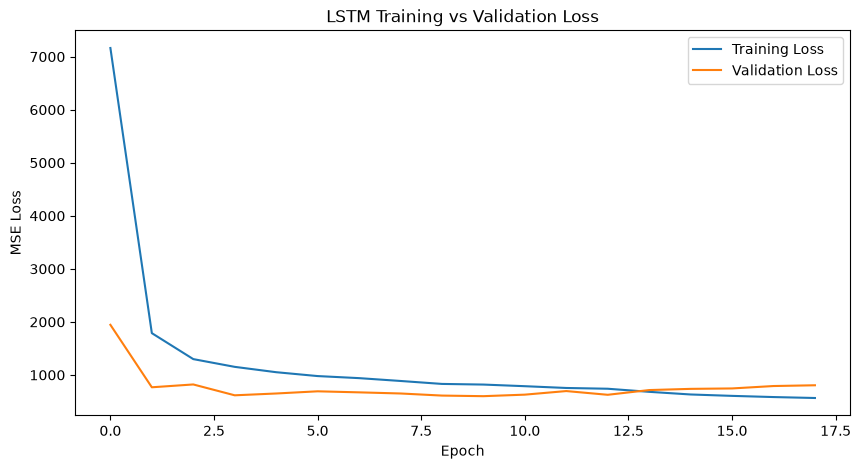

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM Training vs Validation Loss')
plt.legend()
plt.show()

### RUL-range Error Analysis

In [47]:
import pandas as pd
import numpy as np

results_lstm = pd.DataFrame({
    "Actual_RUL": y_val_lstm,
    "Predicted_RUL": y_pred_lstm
})

results_lstm["Error"] = (
    results_lstm["Actual_RUL"] -
    results_lstm["Predicted_RUL"]
)

results_lstm["Absolute_Error"] = (
    results_lstm["Error"].abs()
)

results_lstm.head()

,Actual_RUL,Predicted_RUL,Error,Absolute_Error
0,162,166.540543,-4.540543,4.540543
1,161,161.134338,-0.134338,0.134338
2,160,167.241104,-7.241104,7.241104
3,159,175.003601,-16.003601,16.003601
4,158,177.969040,-19.969040,19.969040


In [48]:
bins = [-np.inf, 30, 60, 100, np.inf]

labels = [
    "0-30",
    "31-60",
    "61-100",
    "100+"
]

results_lstm["RUL_Range"] = pd.cut(
    results_lstm["Actual_RUL"],
    bins=bins,
    labels=labels
)

In [49]:
range_analysis = results_lstm.groupby(
    "RUL_Range",
    observed=False
).agg(
    Samples=("Actual_RUL", "count"),
    MAE=("Absolute_Error", "mean"),
    RMSE=("Error", lambda x: np.sqrt(np.mean(x**2))),
    Mean_Error=("Error", "mean")
).reset_index()

range_analysis

,RUL_Range,Samples,MAE,RMSE,Mean_Error
0,0-30,620,4.323361,5.407406,-1.618482
1,31-60,600,9.105091,12.259493,-3.562287
2,61-100,800,18.636262,23.884323,-11.953389
3,100+,1470,25.778074,32.248125,9.554034


In [55]:
results_lstm["Error_Type"] = np.where(
    results_lstm["Error"] > 0,
    "Underprediction",
    "Overprediction"
)

results_lstm["Error_Type"].value_counts()

Error_Type
Overprediction     1834
Underprediction    1656
Name: count, dtype: int64

The model predicted fewer remaining cycles than actually existed → underprediction.

The model predicted more remaining life than actually existed → overprediction.

### Tuned LSTM

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(
        64,
        input_shape=(
            X_train_lstm.shape[1],
            X_train_lstm.shape[2]
        ),
        return_sequences=False
    ),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dropout(0.2),

    Dense(1)
])

d:\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [34]:
history = model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=100,
    batch_size=64,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 5893.7935 - mae: 55.2855 - val_loss: 1155.9462 - val_mae: 23.9663 - learning_rate: 0.0010
Epoch 2/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1643.4193 - mae: 28.0417 - val_loss: 744.0497 - val_mae: 20.0661 - learning_rate: 0.0010
Epoch 3/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1383.1737 - mae: 25.5121 - val_loss: 657.6748 - val_mae: 18.2083 - learning_rate: 0.0010
Epoch 4/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1219.7314 - mae: 23.6535 - val_loss: 600.3384 - val_mae: 17.0794 - learning_rate: 0.0010
Epoch 5/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1153.3928 - mae: 23.0638 - val_loss: 576.0534 - val_mae: 16.9511 - learning_rate: 0.0010
Epoch 6/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1037.4441 - mae: 21.9549 - val_loss: 640.2772 - val_mae: 18.2215 - learning_rate: 0.0010
Epoch 7/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1040.0380 - mae: 21.8234 - val_

In [35]:
val_loss, val_mae = model.evaluate(
    X_val_lstm,
    y_val_lstm,
    verbose=0
)

print("Validation Loss:", val_loss)
print("Validation MAE:", val_mae)

Validation Loss: 526.9534912109375
Validation MAE: 16.842824935913086


In [38]:
y_pred_lstm2 = model.predict(
    X_val_lstm
).flatten()

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [45]:
model.save("lstm_rul_model.keras")

In [40]:
mae_lstm2 = mean_absolute_error(
    y_val_lstm,
    y_pred_lstm2
)

rmse_lstm2 = np.sqrt(
    mean_squared_error(
        y_val_lstm,
        y_pred_lstm2
    )
)

r2_lstm2 = r2_score(
    y_val_lstm,
    y_pred_lstm2
)

print("LSTM Results")
print("----------------")
print("MAE :", mae_lstm2)
print("RMSE:", rmse_lstm2)
print("R²  :", r2_lstm2)

LSTM Results
----------------
MAE : 16.842824935913086
RMSE: 22.95546889623677
R²  : 0.844677209854126


In [41]:
results_lstm2 = pd.DataFrame({
    "Actual_RUL": y_val_lstm,
    "Predicted_RUL": y_pred_lstm2
})

results_lstm2["Error"] = (
    results_lstm2["Actual_RUL"] -
    results_lstm2["Predicted_RUL"]
)

results_lstm2["Absolute_Error"] = (
    results_lstm2["Error"].abs()
)

results_lstm2.head()

,Actual_RUL,Predicted_RUL,Error,Absolute_Error
0,162,189.047058,-27.047058,27.047058
1,161,188.808029,-27.808029,27.808029
2,160,191.742569,-31.742569,31.742569
3,159,191.988846,-32.988846,32.988846
4,158,187.699295,-29.699295,29.699295


In [42]:
bins = [-np.inf, 30, 60, 100, np.inf]

labels = [
    "0-30",
    "31-60",
    "61-100",
    "100+"
]

results_lstm2["RUL_Range"] = pd.cut(
    results_lstm2["Actual_RUL"],
    bins=bins,
    labels=labels
)

In [43]:
range_analysis2 = results_lstm2.groupby(
    "RUL_Range",
    observed=False
).agg(
    Samples=("Actual_RUL", "count"),
    MAE=("Absolute_Error", "mean"),
    RMSE=("Error", lambda x: np.sqrt(np.mean(x**2))),
    Mean_Error=("Error", "mean")
).reset_index()

range_analysis2

,RUL_Range,Samples,MAE,RMSE,Mean_Error
0,0-30,620,4.440693,5.718302,-2.369786
1,31-60,600,9.168880,12.708996,-3.800077
2,61-100,800,16.776950,21.143162,-9.928620
3,100+,1470,25.241728,30.464173,10.769379


In [44]:
results_lstm2["Error_Type"] = np.where(
    results_lstm2["Error"] > 0,
    "Underprediction",
    "Overprediction"
)

results_lstm2["Error_Type"].value_counts()

Error_Type
Overprediction     1843
Underprediction    1647
Name: count, dtype: int64

### Stacked LSTM

In [24]:
model = Sequential([
    LSTM(
        64,
        return_sequences=True,
        input_shape=(
            X_train_lstm.shape[1],
            X_train_lstm.shape[2]
        )
    ),

    Dropout(0.2),

    LSTM(32),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(1)
])

d:\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [25]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [26]:
history = model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=100,
    batch_size=64,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 8234.0000 - mae: 69.1305 - val_loss: 2831.7712 - val_mae: 36.7205 - learning_rate: 0.0010
Epoch 2/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 2054.3066 - mae: 29.8581 - val_loss: 834.3315 - val_mae: 19.9594 - learning_rate: 0.0010
Epoch 3/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 1246.9379 - mae: 23.4742 - val_loss: 685.7759 - val_mae: 19.1209 - learning_rate: 0.0010
Epoch 4/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 1028.2333 - mae: 21.4868 - val_loss: 631.2489 - val_mae: 17.4251 - learning_rate: 0.0010
Epoch 5/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 914.2441 - mae: 20.3012 - val_loss: 827.0211 - val_mae: 20.2784 - learning_rate: 0.0010
Epoch 6/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 829.6033 - mae: 19.6318 - val_loss: 649.7252 - val_mae: 18.4841 - learning_rate: 0.0010
Epoch 7/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 699.0806 - mae: 18.0296 - val_lo

In [27]:
val_loss, val_mae = model.evaluate(
    X_val_lstm,
    y_val_lstm,
    verbose=0
)

print("Validation Loss:", val_loss)
print("Validation MAE:", val_mae)

Validation Loss: 631.2490844726562
Validation MAE: 17.425046920776367


In [28]:
y_pred_lstm = model.predict(
    X_val_lstm
).flatten()

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lstm3 = mean_absolute_error(
    y_val_lstm,
    y_pred_lstm
)

rmse_lstm3 = np.sqrt(
    mean_squared_error(
        y_val_lstm,
        y_pred_lstm
    )
)

r2_lstm3 = r2_score(
    y_val_lstm,
    y_pred_lstm
)

print("LSTM Results")
print("----------------")
print("MAE :", mae_lstm3)
print("RMSE:", rmse_lstm3)
print("R²  :", r2_lstm3)

LSTM Results
----------------
MAE : 17.425050735473633
RMSE: 25.124667189182578
R²  : 0.8139355182647705
